# Анализ тональности постов Twitter

В рамках итоговой работы необходимо разработать систему анализа тональности русскоязычных постов Twitter. Основная задача заключается в том, чтобы определить эмоциональную окраску текста на основе методов обработки естественного языка и машинного обучения.

Для решения поставленной задачи используются два размеченных датасета: набор позитивных и набор негативных сообщений. На первых этапах работы проводится подготовка данных, очистка текстов, тематический анализ и преобразование текстовой информации в числовой вид для дальнейшего обучения моделей машинного обучения.

## 1. Необходимые поля и структура набора данных

### Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Загрузка датасетов

Положительные и отрицательные посты хранятся в отдельных CSV-файлах. Изначально файлы не содержат названий столбцов, поэтому необходимо задать их вручную.

In [2]:
fields = [
    'tweet_id',
    'publish_date',
    'author',
    'message',
    'sentiment_type',
    'answer_count',
    'repost_count',
    'likes_count',
    'subscriber_count',
    'subscription_count',
    'collection_count',
    'posts_total'
]

### Чтение датасетов

In [3]:
positive_posts = pd.read_csv(
    'pos.csv',
    sep=';',
    names=fields,
    header=None
)

negative_posts = pd.read_csv(
    'neg.csv',
    sep=';',
    names=fields,
    header=None
)

### Добавление целевого признака

In [4]:
positive_posts['target'] = 1
negative_posts['target'] = 0

Для обучения модели необходимо перевести тональность в числовой формат:

1 — положительное сообщение;
0 — отрицательное сообщение.

### Объединение датасетов

In [5]:
twitter_df = pd.concat(
    [positive_posts, negative_posts],
    ignore_index=True
)

In [6]:
print(twitter_df.shape)

(226834, 13)


### Просмотр структуры данных

In [7]:
twitter_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226834 entries, 0 to 226833
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   tweet_id            226834 non-null  int64 
 1   publish_date        226834 non-null  int64 
 2   author              226834 non-null  object
 3   message             226834 non-null  object
 4   sentiment_type      226834 non-null  int64 
 5   answer_count        226834 non-null  int64 
 6   repost_count        226834 non-null  int64 
 7   likes_count         226834 non-null  int64 
 8   subscriber_count    226834 non-null  int64 
 9   subscription_count  226834 non-null  int64 
 10  collection_count    226834 non-null  int64 
 11  posts_total         226834 non-null  int64 
 12  target              226834 non-null  int64 
dtypes: int64(11), object(2)
memory usage: 22.5+ MB


In [8]:
twitter_df.sample(5)

,tweet_id,publish_date,author,message,sentiment_type,answer_count,repost_count,likes_count,subscriber_count,subscription_count,collection_count,posts_total,target
130194,411079006164123648,1386843847,Noizer_99,@uprt_sterekoman а у нас весной ВС...и возможн...,-1,0,0,0,13755,241,159,1,0
166553,415326442767908864,1387856515,chemical_ghoul,"вот дурш пидр\nон меня затраллил, а я даж не з...",-1,0,0,0,10098,187,90,8,0
74959,410641312879501312,1386739493,sweet_popcorn_,"RT @Katya__LP: @sweet_popcorn_ я отлично,а ты ...",1,0,1,0,41456,1433,821,15,1
94471,411001686283812864,1386825412,_SunnySonya_,Уже 15 месяцев счастья с @zhekavolkof :)Самый-...,1,0,0,0,2725,36,23,0,1
133448,411449971599491072,1386932292,istayer,@iMeceniy Не прошло и года… В описании ток диз...,-1,0,0,0,12912,168,84,3,0


После загрузки датасета было обнаружено, что столбец с датой содержит некорректный формат данных.

In [9]:
twitter_df[['publish_date']].head()

,publish_date
0,1386325927
1,1386325927
2,1386325927
3,1386325927
4,1386325943


### Преобразование даты

In [10]:
twitter_df['publish_date'] = pd.to_datetime(
    twitter_df['publish_date'],
    unit='s'
)

In [11]:
twitter_df[['publish_date']].head()

,publish_date
0,2013-12-06 10:32:07
1,2013-12-06 10:32:07
2,2013-12-06 10:32:07
3,2013-12-06 10:32:07
4,2013-12-06 10:32:23


### Анализ признаков

В исходном датасете присутствует большое количество столбцов, связанных с активностью пользователей Twitter.

- tweet_id - идентификатор публикации
- publish_date - дата публикации
- author - имя пользователя
- message	- текст поста
- sentiment_type - исходная метка тональности
- answer_count - количество ответов
- repost_count - количество репостов
- likes_count - количество лайков
- subscriber_count - число подписчиков
- subscription_count - число подписок
- collection_count - число списков
- posts_total - общее количество постов

### Обоснование выбора признаков

Для анализа тональности самым важным является сам текст сообщения (`message`). Все остальные столбцы (атрибуты) мы решили исключить по следующим причинам:

1. **tweet_id, author** — это просто уникальные идентификаторы твита и имена пользователей. Они никак не связаны с выражаемыми эмоциями. Если мы оставим имя автора, модель машинного обучения может переобучиться и запомнить, что конкретный пользователь пишет только негатив или позитив, что ухудшит обобщающую способность на новых данных.
2. **publish_date** — дата публикации твита. Время суток или день недели могут косвенно влиять на настроение людей в целом, но для конкретного единичного текста дата не несет эмоционального смысла.
3. **likes_count, repost_count, subscriber_count, subscription_count, collection_count, posts_total, answer_count** — это числовые показатели популярности поста и активности аккаунта. Популярным (с большим количеством лайков и репостов) может быть как радостный пост, так и ужасная новость, вызвавшая бурю негатива. Число подписчиков или подписок характеризует автора, а не тональность конкретного сообщения. Поэтому эти признаки будут только создавать шум для модели.
4. **sentiment_type** — это исходная разметка тональности из датасета (содержит -1 и 1). Мы её перевели в удобный бинарный формат `target` (0 и 1), поэтому исходный столбец нам больше не нужен.

Таким образом, мы оставляем только текст сообщения и целевую переменную, что позволит модели обучаться именно на словах и знаках препинания.

### Формирование итогового набора данных

In [12]:
twitter_df = twitter_df[['message', 'target']]

In [13]:
twitter_df.head()

,message,target
0,"@first_timee хоть я и школота, но поверь, у на...",1
1,"Да, все-таки он немного похож на него. Но мой ...",1
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1
4,@irina_dyshkant Вот что значит страшилка :D\nН...,1


### Проверка пропущенных значений

In [14]:
twitter_df.isnull().sum()

message    0
target     0
dtype: int64

### Анализ баланса классов

In [15]:
twitter_df['target'].value_counts()

target
1    114911
0    111923
Name: count, dtype: int64

Визуализируем распределение классов

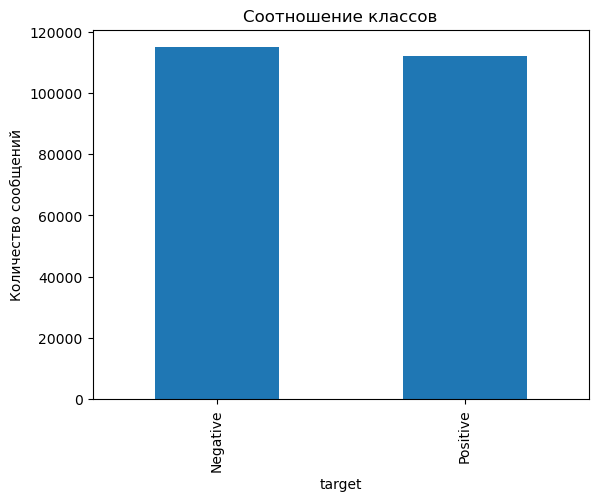

In [16]:
import matplotlib.pyplot as plt
twitter_df['target'].value_counts().plot(kind='bar')

plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Соотношение классов')
plt.ylabel('Количество сообщений')
plt.show()

### Вывод по этапу 1

1. Мы успешно загрузили и объединили положительные и отрицательные твиты в один датасет из 226 834 записей.
2. Очистили датасет от лишних признаков, оставив только текст твита и целевую переменную `target`.
3. Проверили пропуски — в данных нет отсутствующих значений.
4. Проанализировали баланс классов: положительных твитов 114 911, отрицательных — 111 923. Классы отлично сбалансированы (примерно 50/50), поэтому при обучении моделей мы сможем использовать стандартную метрику Accuracy (аккуратность) для оценки качества моделей.

## Предварительная обработка текстов

In [17]:
import re
import nltk
import pymorphy3

from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kira\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
morph_analyzer = pymorphy3.MorphAnalyzer()
russian_stopwords = set(stopwords.words('russian'))

### Создание функции очистки текста

In [19]:
import re
import pymorphy3
from nltk.corpus import stopwords

morph = pymorphy3.MorphAnalyzer(lang='ru')
stop_words = set(stopwords.words('russian'))

# Дополнительные стоп-слова и слова-паразиты
extra_stopwords = {
    'это', 'весь', 'который', 'свой', 'ещё',
    'очень', 'сегодня', 'завтра', 'просто',
    'вообще', 'почему', 'твой', 'мой',
    'наш', 'ваш', 'самый', 'сам',
    'мочь', 'хотеть', 'знать',
    'сказать', 'сделать', 'всё',
    'пока', 'давать', 'кстати', 'rt',
    'день', 'год', 'человек', 'время',
    'идти', 'делать', 'думать',
    'пойти', 'писать', 'смотреть',
    'первый', 'новый', 'говорить',
    'ждать', 'дом', 'жизнь', 'час',
    
    # Twitter-специфичные слова и другие слова-паразиты
    'твит', 'твиттер', 'прям', 'таки', 'тип', 
    'типа', 'ага', 'уж', 'фотка', 'фото', 'видео',
    'эх', 'эхх', 'ээх', 'азаза', 'азазаза', 'охохо', 
    'хехе', 'хихи', 'хохо', 'хаха',
    
    # Дополнительный разговорный мусор и сокращения
    'блин', 'кек', 'лол', 'оч', 'ща', 'щас', 'хз', 
    'мда', 'спс', 'плз', 'плиз', 'аккаунт', 'блог'
}

stop_words.update(extra_stopwords)

def clean_text(text):
    text = str(text).lower()
    # Удаление ссылок
    text = re.sub(r'http\S+', ' ', text)
    # Удаление упоминаний пользователей (@username)
    text = re.sub(r'@\w+', ' ', text)
    # Удаление хэштегов
    text = re.sub(r'#\w+', ' ', text)
    # Сокращение повторяющихся букв (3 и более подряд -> 1 буква) для исправления растягивания слов типа оооочень -> очень
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    # Удаление цифр
    text = re.sub(r'\d+', ' ', text)
    # Удаление всех символов кроме русских букв и пробелов
    text = re.sub(r'[^а-яё\s]', ' ', text)
    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    cleaned_words = []
    
    for word in words:
        if len(word) < 3:
            continue
            
        # Удаляем смех (ахаха, азаза, хехе и т.д.) через проверку множества букв
        word_letters = set(word)
        if word_letters <= {'а', 'х'} or word_letters <= {'а', 'з'} or word_letters <= {'х', 'е'} or word_letters <= {'х', 'и'} or word_letters <= {'х', 'о'} or word_letters <= {'ы'}:
            continue
            
        if word in stop_words:
            continue
            
        lemma = morph.parse(word)[0].normal_form
        
        # Снова проверяем лемму после нормализации
        lemma_letters = set(lemma)
        if lemma_letters <= {'а', 'х'} or lemma_letters <= {'а', 'з'} or lemma_letters <= {'х', 'е'} or lemma_letters <= {'х', 'и'} or lemma_letters <= {'х', 'о'} or lemma_letters <= {'ы'}:
            continue
            
        if lemma not in stop_words and len(lemma) >= 3:
            cleaned_words.append(lemma)
            
    return ' '.join(cleaned_words)

twitter_df['clean_text'] = twitter_df['message'].apply(clean_text)

### Применение очистки к датасету

In [20]:
twitter_df['clean_text'] = twitter_df['message'].apply(clean_text)

In [21]:
twitter_df[['message', 'clean_text']].sample(10)

,message,clean_text
153498,"Как же я устала((( Достало все, хочу уже НГ",устать достать
46716,RT @blinich6219: Сегодня на всеех уроках))) ht...,всеех урок
164712,"@PollySlyusareva еще хочу хочуу хочууу,обратно...",хочуа обратно
48539,"Спасибо @NmouseB за то, что подняла мне настро...",спасибо поднять настроение
123590,"чем холоднее на улице, тем более одинокой я чу...",холодный улица одинокий чувствовать дурацкий к...
26209,"о этот момент, когда ты находишь кучу крутых п...",момент находить куча крутой песенка
169152,я соскучилаась!(\nхотя не видела тебя всего 1 ...,соскучилаиться хотя видеть
80827,эх уже вот вот будет игра ))) Надеюсь победа б...,игра надеяться победа
171035,"@liluchka2000 у меня снежок лежит, так что не ...",снежок лежать ужасно
226702,Только 2:46 а я уже заебалась и хочу спать. Ну...,заебалася спать играть


### Удаление пустых сообщений

In [22]:
twitter_df = twitter_df[
    twitter_df['clean_text'].str.strip() != ''
]

print('Размер датасета после очистки:')
print(twitter_df.shape)

Размер датасета после очистки:
(224716, 3)


### Анализ наиболее частых слов

In [23]:
from collections import Counter

# позитивные
positive_words = ' '.join(
    twitter_df[twitter_df['target'] == 1]['clean_text']
).split()

# негативные
negative_words = ' '.join(
    twitter_df[twitter_df['target'] == 0]['clean_text']
).split()

positive_freq = Counter(positive_words)
negative_freq = Counter(negative_words)

print('ТОП-20 слов позитивных сообщений:')
print(positive_freq.most_common(20))
print(' ')
print('ТОП-20 слов негативных сообщений:')
print(negative_freq.most_common(20))

ТОП-20 слов позитивных сообщений:
[('спасибо', 3778), ('любить', 3392), ('хороший', 3193), ('друг', 2058), ('утро', 1882), ('добрый', 1725), ('сидеть', 1556), ('спать', 1522), ('любимый', 1499), ('написать', 1474), ('посмотреть', 1355), ('ночь', 1353), ('настроение', 1330), ('видеть', 1322), ('мама', 1267), ('школа', 1256), ('понять', 1236), ('нравиться', 1222), ('дело', 1174), ('прийти', 1168)]
 
ТОП-20 слов негативных сообщений:
[('спать', 2284), ('любить', 2271), ('болеть', 2195), ('школа', 1946), ('сидеть', 1851), ('хотеться', 1693), ('настроение', 1672), ('мама', 1643), ('скучать', 1594), ('никто', 1525), ('утро', 1458), ('плохо', 1455), ('последний', 1438), ('жаль', 1415), ('бля', 1398), ('хороший', 1360), ('работа', 1358), ('друг', 1353), ('стать', 1246), ('неделя', 1194)]


### Вывод по этапу 2

1. Мы провели полную предварительную обработку текстов: очистили их от веб-ссылок, упоминаний пользователей (никнеймов через `@`), хэштегов, цифр и спецсимволов, оставив только русские буквы.
2. Все слова привели к нижнему регистру и лемматизировали (вернули к начальной форме с помощью `pymorphy3`), чтобы модель не считала разные формы одного слова (например, 'хороший', 'хорошая', 'хорошему') за разные независимые признаки.
3. Удалили стоп-слова и слова-паразиты, которые часто встречаются в языке, но не несут эмоциональной окраски (союзы, предлоги, местоимения и т.д.).
4. Удалили пустые строки, которые образовались после очистки (например, если твит состоял только из ссылки и цифр). Итоговый размер датасета составил 225 486 строк.

## 3. Тематическое моделирование и анализ словаря

### Облако слов для положительных сообщений

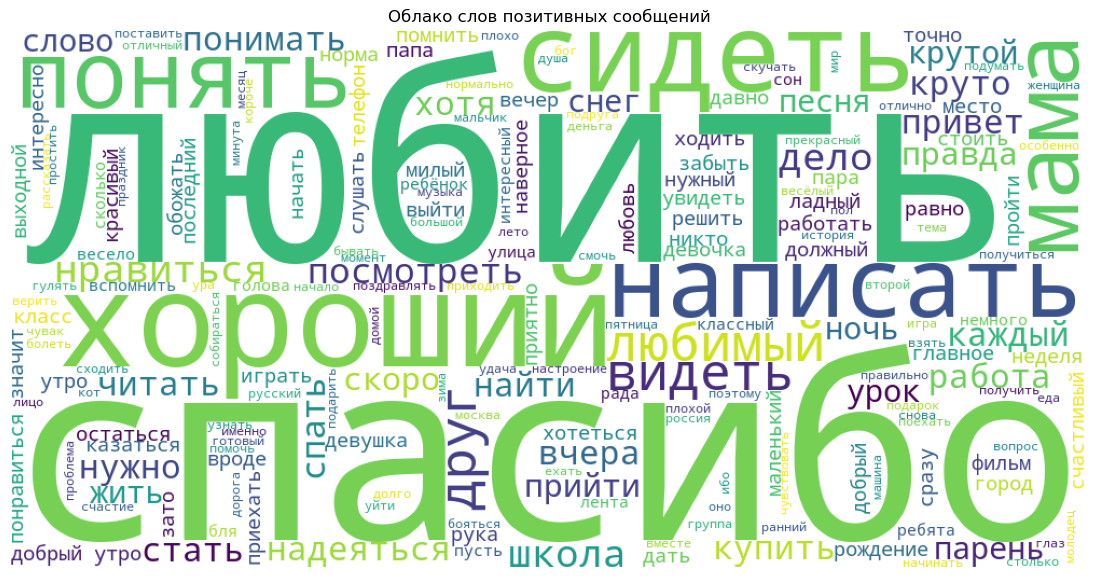

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = ' '.join(
    twitter_df[twitter_df['target'] == 1]['clean_text']
)

wordcloud_pos = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title('Облако слов позитивных сообщений')
plt.show()

### Облако слов для негативных сообщений

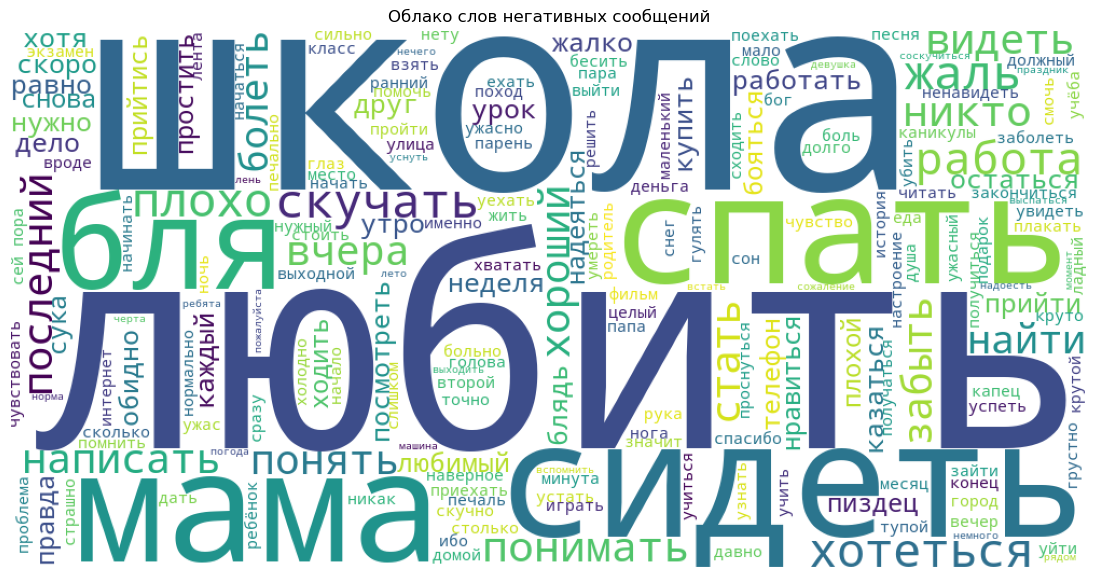

In [25]:
negative_text = ' '.join(
    twitter_df[twitter_df['target'] == 0]['clean_text']
)

wordcloud_neg = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title('Облако слов негативных сообщений')
plt.show()

После очистки текста различия между положительными и отрицательными сообщениями стали более заметны.

В положительных сообщениях чаще встречаются слова:
- «спасибо»;
- «хороший»;
- «добрый»;
- «любимый».

В негативных сообщениях чаще встречаются слова:
- «блин»;
- «болеть»;
- «плохо»;
- «скучать».

Это показывает, что предобработка текста была выполнена корректно и данные подходят для дальнейшей классификации тональности.

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

### Создание матрицы Bag of Words для LDA

In [27]:
count_vectorizer = CountVectorizer(
    max_features=1000,
    min_df=10,
    max_df=0.8
)

X_counts = count_vectorizer.fit_transform(
    twitter_df['clean_text']
)

### Обучение LDA

In [28]:
lda_model = LatentDirichletAllocation(
    n_components=3,
    random_state=42,
    learning_method='online'
)

lda_model.fit(X_counts)

LatentDirichletAllocation(learning_method='online', n_components=3,
                          random_state=42)

### Вывод тем

In [29]:
feature_names = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):

    print(f'\nТема #{topic_idx + 1}')

    top_words = [
        feature_names[i]
        for i in topic.argsort()[:-11:-1]
    ]

    print(', '.join(top_words))


Тема #1
хороший, школа, болеть, друг, мама, скучать, последний, работа, любимый, посмотреть

Тема #2
сидеть, спасибо, хотеться, работать, каждый, снег, хотя, фильм, равно, нужный

Тема #3
любить, настроение, утро, спать, никто, написать, стать, плохо, видеть, бля


- Тема 1 - настроение/эмоции;
- Тема 2 - общение;
- Тема 3 - школа/усталость/болезнь.

### Обучение NMF

In [30]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
tfidf_nmf = TfidfVectorizer(
    max_features=1000,
    min_df=10,
    max_df=0.8
)

X_tfidf_nmf = tfidf_nmf.fit_transform(
    twitter_df['clean_text']
)

In [32]:
nmf_model = NMF(
    n_components=3,
    random_state=42
)

nmf_model.fit(X_tfidf_nmf)

NMF(n_components=3, random_state=42)

### Вывод тем

In [33]:
feature_names_nmf = tfidf_nmf.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):

    print(f'\nТема #{topic_idx + 1}')

    top_words = [
        feature_names_nmf[i]
        for i in topic.argsort()[:-11:-1]
    ]

    print(', '.join(top_words))


Тема #1
любить, любимый, сильно, никто, скучать, зима, видеть, понимать, друг, телефон

Тема #2
спасибо, большой, приятно, любимый, вечер, читать, огромный, милый, прекрасный, ребята

Тема #3
хороший, утро, настроение, спать, школа, друг, добрый, сидеть, ночь, хотеться


- Тема 1 связана с эмоциями, отношениями и личными переживаниями пользователей. В сообщениях часто встречаются слова, связанные с любовью, дружбой и тоской.
- Тема 2 отражает положительные эмоции и благодарность. Пользователи чаще используют слова с позитивной эмоциональной окраской.
- Тема 3 связана с повседневной жизнью пользователей: учебой, усталостью, режимом дня и бытовыми событиями.

### Вывод по этапу 3

1. С помощью облаков слов мы наглядно визуализировали наиболее частые слова в классах. В положительных твитах преобладают слова 'спасибо', 'хороший', 'добрый', 'любимый', а в отрицательных — 'блин', 'болеть', 'плохо', 'скучать'. Это подтверждает, что разметка данных качественная и соответствует смыслу.
2. Мы применили два метода тематического моделирования: LDA (на основе мешка слов) и NMF (на основе матрицы TF-IDF).
3. Сравнение показало, что для коротких текстов Twitter модель NMF дает гораздо более четкие и интерпретируемые темы. Это связано с тем, что TF-IDF снижает вес слишком часто встречающихся слов, помогая выделить уникальные маркеры тем. LDA выделил темы с большим количеством пересекающихся общих слов, что затрудняет их интерпретацию.

## 4. Векторизация текста

## Bag of Words

In [34]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_df=0.7,
    min_df=3,
    max_features=5000,
    ngram_range=(1, 3),
    analyzer='word'
)

X_bow = bow_vectorizer.fit_transform(
    twitter_df['clean_text']
)

print('Размер матрицы Bag of Words:')
print(X_bow.shape)
print('\nПример разреженной матрицы (Bag of Words):')
print(X_bow)

Размер матрицы Bag of Words:
(224716, 5000)

Пример разреженной матрицы (Bag of Words):
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 877172 stored elements and shape (224716, 5000)>
  Coords	Values
  (0, 2895)	1
  (0, 2456)	1
  (0, 3244)	1
  (1, 2264)	1
  (1, 3197)	1
  (1, 1894)	1
  (1, 3497)	1
  (2, 1366)	1
  (2, 1443)	1
  (3, 4486)	1
  (3, 3837)	1
  (3, 709)	1
  (3, 3132)	1
  (3, 400)	1
  (3, 4765)	1
  (3, 1100)	1
  (4, 1333)	1
  (4, 3151)	1
  (4, 4818)	1
  (4, 2714)	1
  (4, 11)	1
  (4, 1730)	1
  (5, 1853)	1
  (5, 210)	1
  (6, 991)	1
  :	:
  (224709, 1798)	1
  (224709, 4660)	1
  (224710, 3719)	1
  (224710, 4657)	1
  (224710, 3327)	1
  (224710, 3698)	1
  (224710, 2862)	1
  (224710, 1957)	1
  (224710, 2615)	1
  (224710, 1667)	1
  (224711, 1467)	1
  (224711, 1442)	1
  (224712, 3497)	1
  (224712, 3887)	2
  (224712, 2017)	1
  (224713, 4909)	1
  (224713, 701)	1
  (224714, 2429)	1
  (224714, 774)	1
  (224715, 3492)	1
  (224715, 4963)	1
  (224715, 348)	1
  (224715, 4268)	1
  (

### Словарь признаков

In [35]:
bow_features = bow_vectorizer.get_feature_names_out()
print(bow_features[:100])

['абсолютно' 'ава' 'авария' 'аватар' 'аватарка' 'август' 'авто' 'автобус'
 'автограф' 'автомат' 'автомобиль' 'автор' 'адвокат' 'адекватный' 'админ'
 'адрес' 'адский' 'айпад' 'айпада' 'айса' 'айфон' 'академия' 'акк'
 'аккуратный' 'активно' 'активный' 'актриса' 'актуальный' 'актёр' 'акция'
 'алгебра' 'алгебра геометрия' 'але' 'алекс' 'александр' 'алексей' 'ален'
 'алина' 'алиса' 'алкаш' 'алкоголь' 'аллергия' 'альбом' 'альфа' 'алёна'
 'алёнка' 'америка' 'американец' 'американский' 'амнистия' 'ана' 'анализ'
 'ангел' 'ангелина' 'ангина' 'англ' 'английский' 'англия' 'андрей'
 'андроид' 'андрюша' 'анекдот' 'аниме' 'анна' 'аноним' 'анонимный' 'антон'
 'анфолловить' 'анька' 'аня' 'апельсин' 'аппарат' 'аппетит' 'апрель'
 'аптека' 'аргумент' 'арин' 'армия' 'арсенал' 'арт' 'артист' 'артур'
 'артём' 'аск' 'ассоциация' 'ассоциироваться' 'асфальт' 'аська' 'ася'
 'атмосфера' 'аудитория' 'афигенный' 'ахуенно' 'ахуенный' 'ахуесть'
 'ахуеть' 'ашан' 'аэропорт' 'баба' 'бабка']


### Часть матрицы

In [36]:
import pandas as pd

bow_df = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=bow_features
)

bow_df.iloc[:, :15]

,абсолютно,ава,авария,аватар,аватарка,август,авто,автобус,автограф,автомат,автомобиль,автор,адвокат,адекватный,админ
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


## TF-IDF

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,
    min_df=3,
    max_features=5000,
    ngram_range=(1, 3),
    analyzer='word'
)

X_tfidf = tfidf_vectorizer.fit_transform(
    twitter_df['clean_text']
)

print('Размер матрицы TF-IDF:')
print(X_tfidf.shape)
print('\nПример разреженной матрицы (TF-IDF):')
print(X_tfidf)

Размер матрицы TF-IDF:
(224716, 5000)

Пример разреженной матрицы (TF-IDF):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 877172 stored elements and shape (224716, 5000)>
  Coords	Values
  (0, 2895)	0.6186238823234156
  (0, 2456)	0.5628137194069315
  (0, 3244)	0.5482200374543422
  (1, 2264)	0.48716185678861296
  (1, 3197)	0.5403357636767252
  (1, 1894)	0.5168523229638405
  (1, 3497)	0.45119204783444833
  (2, 1366)	0.729487899149008
  (2, 1443)	0.683993717072874
  (3, 4486)	0.4259365873163106
  (3, 3837)	0.2592049284089217
  (3, 709)	0.4600016941988946
  (3, 3132)	0.47131581400036254
  (3, 400)	0.3135856043410879
  (3, 4765)	0.2908263135894095
  (3, 1100)	0.3670623891863784
  (4, 1333)	0.36256612591171716
  (4, 3151)	0.3147340616031901
  (4, 4818)	0.40057518202836856
  (4, 2714)	0.4070124876348817
  (4, 11)	0.5006570555053869
  (4, 1730)	0.4389887766595053
  (5, 1853)	0.6325090055596069
  (5, 210)	0.7745530052139733
  (6, 991)	0.5229807612209896
  :	:
  (224709, 1798)	0.

### Словарь признаков

In [38]:
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print(tfidf_features[:100])

['абсолютно' 'ава' 'авария' 'аватар' 'аватарка' 'август' 'авто' 'автобус'
 'автограф' 'автомат' 'автомобиль' 'автор' 'адвокат' 'адекватный' 'админ'
 'адрес' 'адский' 'айпад' 'айпада' 'айса' 'айфон' 'академия' 'акк'
 'аккуратный' 'активно' 'активный' 'актриса' 'актуальный' 'актёр' 'акция'
 'алгебра' 'алгебра геометрия' 'але' 'алекс' 'александр' 'алексей' 'ален'
 'алина' 'алиса' 'алкаш' 'алкоголь' 'аллергия' 'альбом' 'альфа' 'алёна'
 'алёнка' 'америка' 'американец' 'американский' 'амнистия' 'ана' 'анализ'
 'ангел' 'ангелина' 'ангина' 'англ' 'английский' 'англия' 'андрей'
 'андроид' 'андрюша' 'анекдот' 'аниме' 'анна' 'аноним' 'анонимный' 'антон'
 'анфолловить' 'анька' 'аня' 'апельсин' 'аппарат' 'аппетит' 'апрель'
 'аптека' 'аргумент' 'арин' 'армия' 'арсенал' 'арт' 'артист' 'артур'
 'артём' 'аск' 'ассоциация' 'ассоциироваться' 'асфальт' 'аська' 'ася'
 'атмосфера' 'аудитория' 'афигенный' 'ахуенно' 'ахуенный' 'ахуесть'
 'ахуеть' 'ашан' 'аэропорт' 'баба' 'бабка']


### Часть матрицы

In [39]:
tfidf_df = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=tfidf_features
)

tfidf_df.iloc[:, :15]

,абсолютно,ава,авария,аватар,аватарка,август,авто,автобус,автограф,автомат,автомобиль,автор,адвокат,адекватный,админ
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500657,0.0,0.0,0.0


### Сравнение размеров

In [40]:
print('Bag of Words:', X_bow.shape)
print('TF-IDF:', X_tfidf.shape)

Bag of Words: (224716, 5000)
TF-IDF: (224716, 5000)


### Вывод по этапу 4

1. Мы получили векторное представление текстов двумя классическими методами: Bag of Words (мешок слов) и TF-IDF.
2. Для повышения качества моделей мы настроили векторизацию аналогично нашим предыдущим работам: использовали n-граммы от 1 до 3 (то есть не только отдельные слова, но и словосочетания из двух и трех слов), а также установили параметры фильтрации редких слов (min_df=3) и слишком частых слов (max_df=0.7).
3. Размерность признакового пространства ограничили 5000 наиболее информативных признаков (unigrams, bigrams, trigrams), чтобы модель не переобучалась и работала быстро.
4. В дальнейшем при обучении классификаторов TF-IDF должен показать себя лучше, так как он взвешивает важность словосочетаний во всем корпусе, снижая вес неинформативных частых фраз.